In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def compute_center(X):
    means = np.mean(X, axis=0)
    X_centered = X - means
    return X_centered, means

In [19]:
def compute_covariance_matrix(X_centered):
    n_samples = X_centered.shape[0]
    covariance_matrix = np.dot(X_centered.T, X_centered) / (n_samples - 1)
    return covariance_matrix

In [20]:
def eigendecompose_covariance_matrix(covariance_matrix):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    return eigenvalues, eigenvectors

In [21]:
def select_top_k_components(eigenvalues, eigenvectors, k):
    top_k_eigenvalues = eigenvalues[:k]
    top_k_eigenvectors = eigenvectors[:, :k]
    return top_k_eigenvalues, top_k_eigenvectors

In [22]:
def project_data(X_centered, top_k_eigenvectors):
    projected_data = np.dot(X_centered, top_k_eigenvectors)
    return projected_data

In [23]:
def pca(X, k):
    X_centered, means = compute_center(X)
    covariance_matrix = compute_covariance_matrix(X_centered)
    eigenvalues, eigenvectors = eigendecompose_covariance_matrix(covariance_matrix)
    top_k_eigenvalues, top_k_eigenvectors = select_top_k_components(eigenvalues, eigenvectors, k)
    projected_data = project_data(X_centered, top_k_eigenvectors)
    return projected_data, top_k_eigenvalues, top_k_eigenvectors

In [24]:
# Create a small 2D correlated dataset
rng = np.random.default_rng(42)

n_points = 40
pc1 = rng.normal(0, 2.0, size=n_points)
pc2 = rng.normal(0, 0.45, size=n_points)

theta = np.deg2rad(35)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)],
])

X = np.column_stack([pc1, pc2]) @ R.T
X[:5]

array([[ 0.30737835,  0.62353425],
       [-1.84400343, -0.99280409],
       [ 1.40124157,  0.61556311],
       [ 1.481008  ,  1.16455046],
       [-3.22650663, -2.19512308]])

In [25]:
# Run PCA
Z1, eigenvalues_1d, W1 = pca(X, k=1)
Z2, eigenvalues_2d, W2 = pca(X, k=2)

X_centered, means = compute_center(X)
cov_matrix = compute_covariance_matrix(X_centered)
all_eigenvalues, all_eigenvectors = eigendecompose_covariance_matrix(cov_matrix)
explained_variance_ratio = all_eigenvalues / all_eigenvalues.sum()

print("X shape:", X.shape)
print("Z1 shape:", Z1.shape)
print("Z2 shape:", Z2.shape)
print("covariance matrix:\n", cov_matrix)
print("eigenvalues:", all_eigenvalues)
print("explained variance ratio:", explained_variance_ratio)

X shape: (40, 2)
Z1 shape: (40, 1)
Z2 shape: (40, 2)
covariance matrix:
 [[1.97589797 1.19116322]
 [1.19116322 0.8600174 ]]
eigenvalues: [2.73331588 0.10259949]
explained variance ratio: [0.96382138 0.03617862]


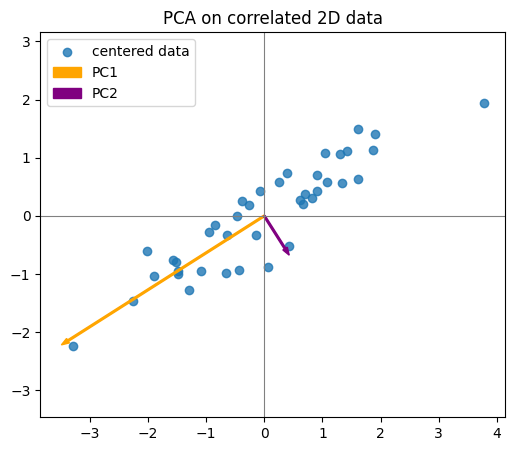

In [26]:
# Visualize data and principal directions
plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.8, label="centered data")

origin = np.array([0, 0])
scale = 2.5
pc1_vec = all_eigenvectors[:, 0] * np.sqrt(all_eigenvalues[0]) * scale
pc2_vec = all_eigenvectors[:, 1] * np.sqrt(all_eigenvalues[1]) * scale

plt.arrow(*origin, *pc1_vec, color="orange", width=0.03, length_includes_head=True, label="PC1")
plt.arrow(*origin, *pc2_vec, color="purple", width=0.03, length_includes_head=True, label="PC2")

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.title("PCA on correlated 2D data")
plt.legend()
plt.show()

In [27]:
def reconstruct_data(Z, W, means):
    return Z @ W.T + means

In [28]:
def reconstruct_error(X, X_reconstructed):
    errors = np.sum((X - X_reconstructed) ** 2, axis=1)
    return errors

In [29]:
# Add a few obvious anomalies away from the main PCA direction
anomalies = np.array([
    [1.2, -3.0],
    [2.0, -2.5],
    [-1.4, 2.7],
])

X_with_anomalies = np.vstack([X, anomalies])
true_labels = np.array([0] * len(X) + [1] * len(anomalies))

X_with_anomalies.shape

(43, 2)

In [30]:
# PCA anomaly detection using reconstruction error
# Fit PCA on normal data, then score all points.
k = 1

X_centered_normal, normal_mean = compute_center(X)
normal_cov = compute_covariance_matrix(X_centered_normal)
normal_eigenvalues, normal_eigenvectors = eigendecompose_covariance_matrix(normal_cov)
_, W_anomaly = select_top_k_components(normal_eigenvalues, normal_eigenvectors, k)

X_all_centered = X_with_anomalies - normal_mean
Z_all = project_data(X_all_centered, W_anomaly)
X_reconstructed = reconstruct_data(Z_all, W_anomaly, normal_mean)
errors = reconstruct_error(X_with_anomalies, X_reconstructed)

normal_errors = errors[:len(X)]
threshold = normal_errors.max() * 1.2
predicted_anomaly = errors > threshold

print("threshold:", threshold)
print("errors:", errors)
print("predicted anomaly:", predicted_anomaly)

threshold: 0.73441821841281
errors: [1.23841653e-01 2.02604093e-02 5.84455531e-02 3.19366988e-02
 1.70102746e-02 7.20886030e-04 1.55077684e-01 3.97651686e-03
 8.66634003e-02 3.00621067e-03 3.95505351e-02 1.18101166e-01
 4.33655561e-01 2.78413137e-03 3.21123452e-02 1.39110925e-01
 1.00435276e-02 3.33429665e-01 1.02671892e-01 1.77683494e-01
 6.12015182e-01 4.85974461e-02 2.97868084e-02 5.78235230e-02
 7.41505668e-02 9.98569641e-02 1.41010242e-02 3.41039225e-02
 1.70646257e-01 3.24971554e-03 1.53907495e-01 3.07974572e-01
 2.19246703e-01 2.01029469e-02 1.19889827e-02 1.61210068e-01
 4.47480162e-02 1.63603500e-04 3.94294292e-02 8.19443764e-03
 1.01427942e+01 1.01895632e+01 9.12208657e+00]
predicted anomaly: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False  True  True  True]


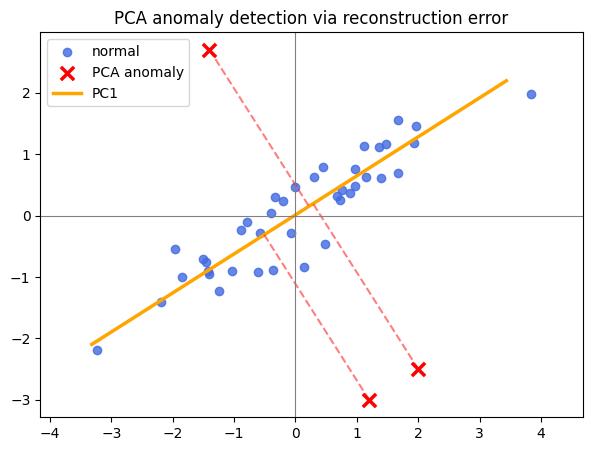

In [31]:
# Plot PCA anomaly result
plt.figure(figsize=(7, 5))

normal_mask = ~predicted_anomaly
anomaly_mask = predicted_anomaly

plt.scatter(
    X_with_anomalies[normal_mask, 0],
    X_with_anomalies[normal_mask, 1],
    color="royalblue",
    alpha=0.8,
    label="normal",
)
plt.scatter(
    X_with_anomalies[anomaly_mask, 0],
    X_with_anomalies[anomaly_mask, 1],
    color="red",
    s=90,
    marker="x",
    linewidths=2.5,
    label="PCA anomaly",
)

# Draw PC1 learned from normal data
pc1_direction = W_anomaly[:, 0]
line_t = np.linspace(-4, 4, 100)
pc1_line = normal_mean + np.outer(line_t, pc1_direction)
plt.plot(pc1_line[:, 0], pc1_line[:, 1], color="orange", linewidth=2.5, label="PC1")

# Optional: connect anomalies to their PCA reconstruction
for i in np.where(anomaly_mask)[0]:
    plt.plot(
        [X_with_anomalies[i, 0], X_reconstructed[i, 0]],
        [X_with_anomalies[i, 1], X_reconstructed[i, 1]],
        color="red",
        linestyle="--",
        alpha=0.5,
    )

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.title("PCA anomaly detection via reconstruction error")
plt.legend()
plt.show()